# Counterfactual Generation — Demo Notebook

Step-by-step walkthrough of the MolCE-based counterfactual methodology (`CF_generator_v3`):

1. **Setup** — paths and imports  
2. **Load** model and split file  
3. **Predict** on the test set  
4. **Pick** a query compound  
5. **Generate** counterfactuals (substituent / core / combination changes)  
6. **Inspect** results  
7. **Visualise** query + top CFs with class probabilities  

---
## 1 — Setup

In [1]:
import sys
from pathlib import Path

# Resolve workspace root regardless of whether the notebook is opened from
# notebooks/ or the repo root.
_ws_root = Path.cwd()
if not (_ws_root / "src").exists():
    _ws_root = _ws_root.parent

if str(_ws_root / "src") not in sys.path:
    sys.path.insert(0, str(_ws_root / "src"))

print(f"Workspace root : {_ws_root}")

Workspace root : c:\Users\lamens\projects\AI_agent\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability


In [2]:
import joblib
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline

from IPython.display import display, Image as IPyImage
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

from chemagent.featurization.fingerprints import ECFP
from chemagent.explainability.Counterfactuals.CF_generator_v3 import CFGenerator
from chemagent.explainability.counterfactual_tools import (
    generate_counterfactuals,
    visualize_counterfactuals,
)

c:\Users\lamens\projects\AI_agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Failed to patch pandas - PandasTools will have limited functionality


---
## 2 — Configuration

Set the paths to your trained model and split file below.

In [3]:
# ── Edit these two paths ────────────────────────────────────────────────────
SPLIT_PATH = _ws_root / (
    "data/logs/session_alamens_20260318_110929_6a0d6a/splits"
    "/chembl_activity_data_O00329_P48736_random.pkl"
)
MODEL_PATH = _ws_root / (
    "data/logs/session_alamens_20260318_110929_6a0d6a/models"
    "/chembl_activity_data_O00329_P48736_random_RFC.pkl"
)
# ────────────────────────────────────────────────────────────────────────────

# Fingerprint settings — must match the model's training setup
N_BITS  = 2048
RADIUS  = 2

print("Split file :", SPLIT_PATH)
print("Model file :", MODEL_PATH)
print("Split exists:", SPLIT_PATH.exists())
print("Model exists:", MODEL_PATH.exists())

Split file : c:\Users\lamens\projects\AI_agent\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\data\logs\session_alamens_20260318_110929_6a0d6a\splits\chembl_activity_data_O00329_P48736_random.pkl
Model file : c:\Users\lamens\projects\AI_agent\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\data\logs\session_alamens_20260318_110929_6a0d6a\models\chembl_activity_data_O00329_P48736_random_RFC.pkl
Split exists: True
Model exists: True


---
## 3 — Load model and split

In [4]:
model      = joblib.load(MODEL_PATH)
split_data = joblib.load(SPLIT_PATH)

print("Split keys :", list(split_data.keys()))
print(f"Train size : {len(split_data['train_smiles'])}")
print(f"Test size  : {len(split_data['test_smiles'])}")
print("Model type :", type(model).__name__)
print("Classes    :", model.classes_)

Split keys : ['train_features', 'train_labels', 'val_features', 'val_labels', 'test_features', 'test_labels', 'train_smiles', 'val_smiles', 'test_smiles']
Train size : 893
Test size  : 384
Model type : RandomForestClassifier
Classes    : [0 1 2]


---
## 4 — Predict on the test set

In [5]:
test_smiles = list(split_data["test_smiles"])
test_labels = list(split_data["test_labels"])  # ground-truth class labels

# Featurize and predict
test_fps   = np.array(ECFP(test_smiles, n_bits=N_BITS, radius=RADIUS))
pred_class = model.predict(test_fps)
pred_proba = model.predict_proba(test_fps)

# Assemble results DataFrame
results_df = pd.DataFrame({
    "smiles"         : test_smiles,
    "true_class"     : test_labels,
    "predicted_class": pred_class,
    "correct"        : (np.array(pred_class) == np.array(test_labels)),
})
for i in range(pred_proba.shape[1]):
    results_df[f"proba_class_{i}"] = pred_proba[:, i]

accuracy = results_df["correct"].mean()
print(f"Test accuracy : {accuracy:.3f}")
print(f"Class distribution (predicted):\n{results_df['predicted_class'].value_counts().to_string()}")
results_df.head()

Test accuracy : 0.932
Class distribution (predicted):
predicted_class
0    306
1     68
2     10


,smiles,true_class,predicted_class,correct,proba_class_0,proba_class_1,proba_class_2
0,COc1ccc(Nc2ncc(CN3CCCN(S(C)(=O)=O)CC3)cc2-c2nc...,0,0,True,0.997143,0.002857,0.000000
1,CNC(=O)CCNc1nc(N2CCOCC2)nc(-n2c(C(F)F)nc3ccccc...,0,0,True,0.976000,0.024000,0.000000
2,CNC(=O)c1cccc(-c2ccc3c(N4CCOCC4C)nc(N4CCOCC4C)...,0,0,True,0.805238,0.040000,0.154762
3,Cc1ncc(-c2cc(-c3cc(S(=O)(=O)NC4CC(O)C4)ccc3C)c...,0,0,True,0.978000,0.000000,0.022000
4,CC(NC(=O)c1c(N)nn2cccnc12)c1cc2cccc(OCc3cnn(C)...,0,0,True,0.879843,0.064364,0.055794


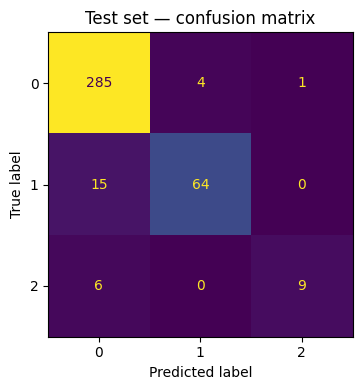

In [6]:
# Quick confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(test_labels, pred_class, labels=sorted(model.classes_))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=sorted(model.classes_)).plot(ax=ax, colorbar=False)
ax.set_title("Test set — confusion matrix")
plt.tight_layout()
plt.show()

---
## 5 — Pick a query compound

Change `QUERY_IDX` to explore different test compounds.  
Tip: pick one the model predicts correctly so the counterfactuals are meaningful.

Using first correctly predicted compound (index 1)
Query SMILES     : CNC(=O)CCNc1nc(N2CCOCC2)nc(-n2c(C(F)F)nc3ccccc32)n1
True class       : 0
Predicted class  : 0
Probabilities    : {'proba_class_0': np.float64(0.976), 'proba_class_1': np.float64(0.024), 'proba_class_2': np.float64(0.0)}


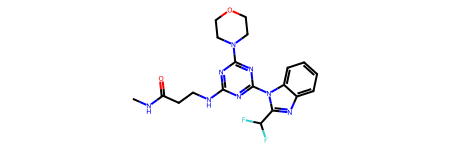

In [7]:
# Index into the test set — change this to explore other compounds
QUERY_IDX = 1

# Optionally iterate to find the first correctly-predicted compound
correct_indices = results_df[results_df["correct"]].index.tolist()
if correct_indices:
    print(f"Using first correctly predicted compound (index {QUERY_IDX})")

row          = results_df.iloc[QUERY_IDX]
query_smiles = row["smiles"]
query_mol    = Chem.MolFromSmiles(query_smiles)

print(f"Query SMILES     : {query_smiles}")
print(f"True class       : {row['true_class']}")
print(f"Predicted class  : {row['predicted_class']}")
proba_cols = [c for c in results_df.columns if c.startswith("proba_class_")]
print("Probabilities    :", {c: round(row[c], 3) for c in proba_cols})

display(query_mol)

---
## 6 — Generate counterfactuals

Three types of perturbation are attempted:
- **substituent** — original scaffold, one R-group swapped from the dataset + static library  
- **core** — original R-groups, Murcko scaffold swapped from the bundled library  
- **combination** — alternative scaffold *and* one R-group changed simultaneously  

In [8]:
cf_result = generate_counterfactuals(
    query_smiles       = query_smiles,
    model_path         = str(MODEL_PATH),
    split_file_path    = str(SPLIT_PATH),
    n_bits             = N_BITS,
    radius             = RADIUS,
    # similarity_threshold = 0.7,   # uncomment to restrict scaffold similarity
    max_counterfactuals = 20,
)

print(f"Status               : {cf_result['status']}")
print(f"Query predicted class: {cf_result['predicted_class']}")
print(f"Query probabilities  : {[round(p, 3) for p in cf_result['probabilities']]}")
print(f"Counterfactuals found: {cf_result['num_counterfactuals']}")

Status               : completed
Query predicted class: 0
Query probabilities  : [0.976, 0.024, 0.0]
Counterfactuals found: 1


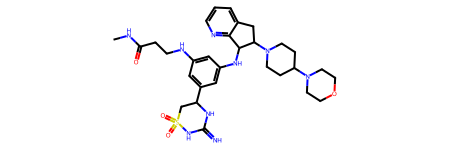

In [9]:
import rdkit
rdkit.Chem.MolFromSmiles(cf_result["counterfactuals"][0]["cf_smiles"])

In [10]:
cf_result

{'query_smiles': 'CNC(=O)CCNc1nc(N2CCOCC2)nc(-n2c(C(F)F)nc3ccccc32)n1',
 'predicted_class': 0,
 'probabilities': [0.976, 0.024, 0.0],
 'n_candidates_tested': 15038,
 'counterfactuals': [{'cf_smiles': 'CNC(=O)CCNc1cc(NC2c3ncccc3CC2N2CCC(N3CCOCC3)CC2)cc(C2CS(=O)(=O)NC(=N)N2)c1',
   'predicted_class': 1,
   'probabilities': [0.4766666666666666, 0.5233333333333333, 0.0],
   'tanimoto_similarity': 0.2727272727272727,
   'change_type': 'combination'}],
 'num_counterfactuals': 1,
 'status': 'completed'}

### 6.1 — Inspect CF DataFrame

In [11]:
cfs = cf_result["counterfactuals"]

if not cfs:
    print("No counterfactuals found — try a different query compound or lower similarity_threshold.")
else:
    cf_df = pd.DataFrame(cfs)
    display(cf_df[[
        "cf_smiles", "predicted_class", "tanimoto_similarity", "change_type"
    ] + [f"proba_class_{i}" for i in range(len(cf_result["probabilities"]))]])

KeyError: "['proba_class_0', 'proba_class_1', 'proba_class_2'] not in index"

### 6.2 — Breakdown by change type

change_type
combination    1


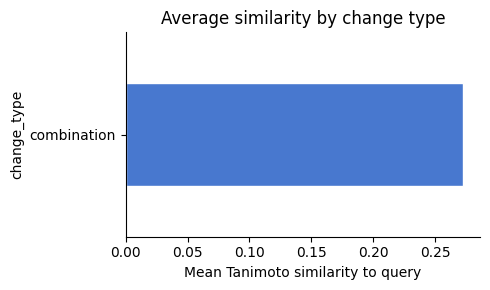

In [12]:
if cfs:
    print(cf_df["change_type"].value_counts().to_string())

    fig, ax = plt.subplots(figsize=(5, 3))
    cf_df.groupby("change_type")["tanimoto_similarity"].mean().sort_values().plot(
        kind="barh", ax=ax, color="#4878CF", edgecolor="white"
    )
    ax.set_xlabel("Mean Tanimoto similarity to query")
    ax.set_title("Average similarity by change type")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

### 6.3 — Draw top counterfactuals (RDKit grid)

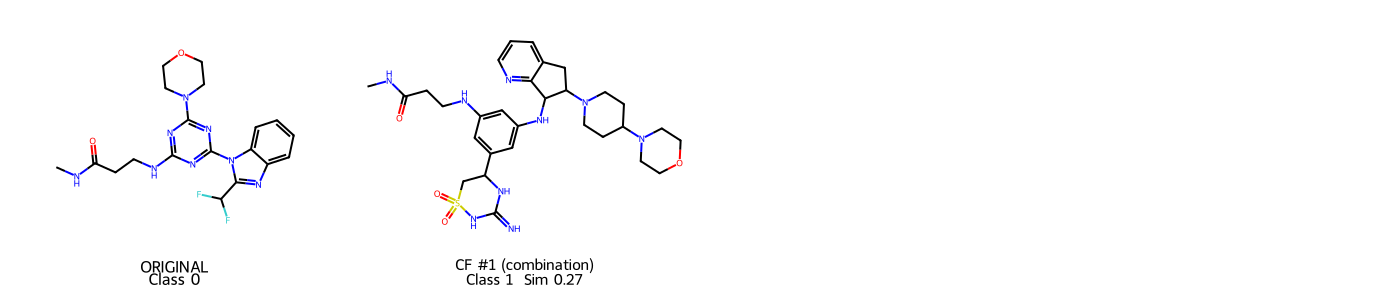

In [13]:
TOP_N = 6  # how many CFs to draw in the quick grid

if cfs:
    mols_to_draw = [query_mol] + [
        Chem.MolFromSmiles(cf["cf_smiles"]) for cf in cfs[:TOP_N]
    ]
    legends = [f"ORIGINAL\nClass {cf_result['predicted_class']}"] + [
        f"CF #{i+1} ({cf['change_type']})\nClass {cf['predicted_class']}  Sim {cf['tanimoto_similarity']:.2f}"
        for i, cf in enumerate(cfs[:TOP_N])
    ]
    img = Draw.MolsToGridImage(
        mols_to_draw,
        molsPerRow=4,
        subImgSize=(350, 300),
        legends=legends,
    )
    display(img)

---
## 7 — Full visualisation with class probabilities

Renders the query and top 3 CFs, each with a probability bar chart.

Saved to: c:\Users\lamens\projects\AI_agent\AI-Agent-for-Compound-Selectivity-Prediction-and-Explainability\notebooks\debug_outputs\counterfactuals_demo.png


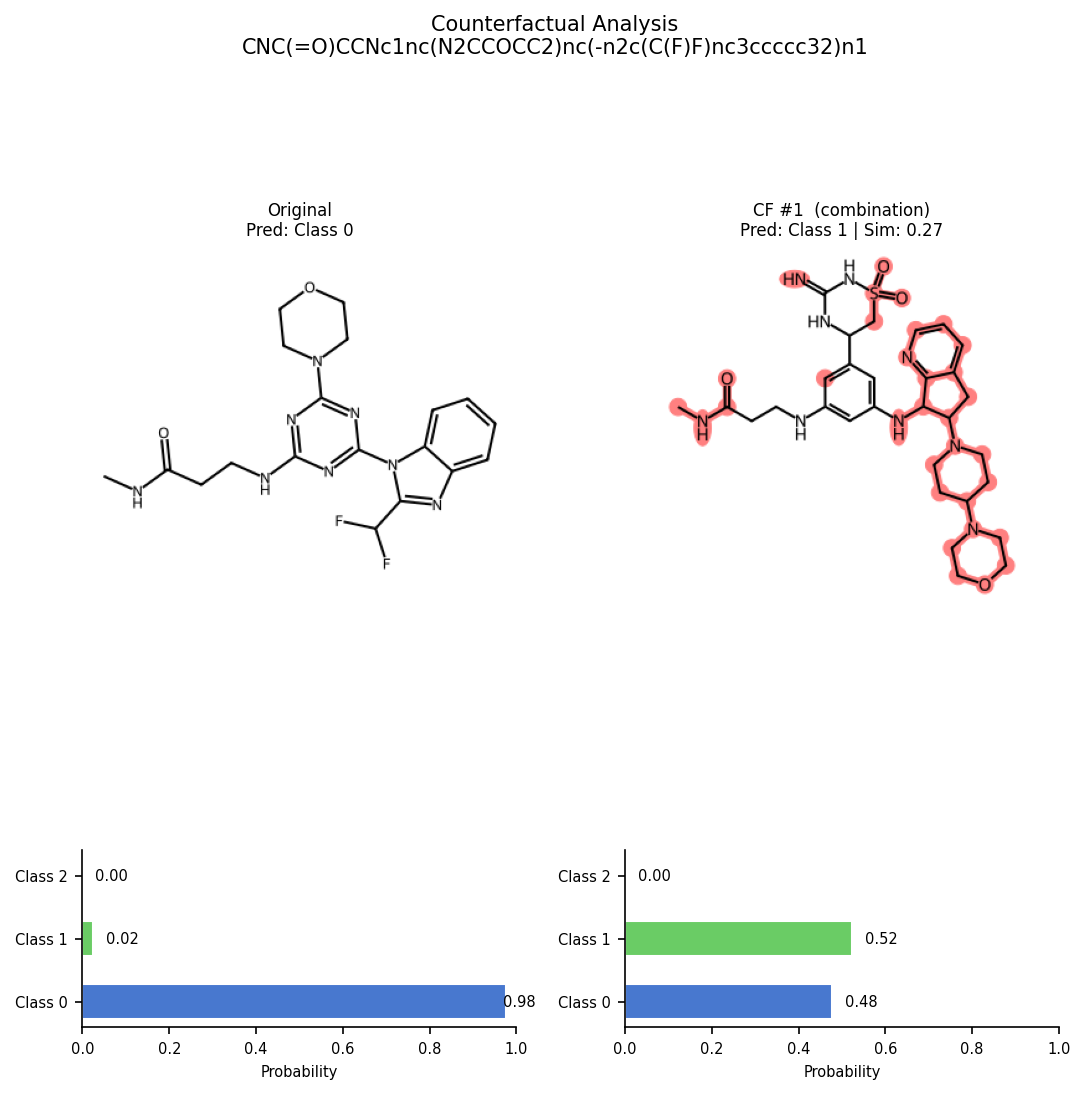

In [14]:
OUT_PATH = _ws_root / "notebooks" / "debug_outputs" / "counterfactuals_demo.png"

viz = visualize_counterfactuals(
    cf_result   = cf_result,
    output_path = str(OUT_PATH),
    top_n       = 3,
)

import json as _json
meta = _json.loads(viz[-1])
print("Saved to:", meta["image_path"])
display(IPyImage(str(OUT_PATH)))

---
## 8 — Low-level access via CFGenerator

Use `CFGenerator` directly if you want to iterate or inspect the raw DataFrame.

In [15]:
# Collect all unique SMILES for the R-group library
all_smiles = list(split_data["train_smiles"]) + list(split_data["test_smiles"])
unique_smiles = list(dict.fromkeys(s for s in all_smiles if s))

gen = CFGenerator(
    query_smiles       = query_smiles,
    model_obj          = model,
    data_smiles        = unique_smiles,
    n_bits             = N_BITS,
    radius             = RADIUS,
    # similarity_threshold = 0.7,
)

print(f"Query class     : {gen.query_class}")
print(f"Query proba     : {[round(p, 3) for p in gen.query_probas]}")
print(f"R-group library : {len(gen._mc.external_rgroups)} entries (dataset + static union)")

Query class     : 0
Query proba     : [0.976, 0.024, 0.0]
R-group library : 776 entries (dataset + static union)


In [16]:
cf_df_raw = gen.find_cfs(max_counterfactuals=30)

print(f"Total CFs returned: {len(cf_df_raw)}")
if not cf_df_raw.empty:
    display(cf_df_raw.drop(columns=["query_smiles", "query_class"], errors="ignore").head(10))

Total CFs returned: 1


,cf_smiles,predicted_class,tanimoto_similarity,change_type,proba_class_0,proba_class_1,proba_class_2
0,CNC(=O)CCNc1cc(NC2c3ncccc3CC2N2CCC(N3CCOCC3)CC...,1,0.272727,combination,0.476667,0.523333,0.0


---
## 9 — Explore multiple query compounds

Loop over the first few correctly-predicted test compounds and print a summary.

In [17]:
N_TO_EXPLORE = 5  # number of compounds to try

summary_rows = []

for idx in correct_indices[:N_TO_EXPLORE]:
    smi = results_df.iloc[idx]["smiles"]
    try:
        res = generate_counterfactuals(
            query_smiles    = smi,
            model_path      = str(MODEL_PATH),
            split_file_path = str(SPLIT_PATH),
            n_bits          = N_BITS,
            radius          = RADIUS,
            max_counterfactuals = 10,
        )
        n_cf  = res["num_counterfactuals"]
        top_sim = (
            round(res["counterfactuals"][0]["tanimoto_similarity"], 3) if n_cf else None
        )
        summary_rows.append({
            "idx"        : idx,
            "smiles"     : smi[:60],
            "pred_class" : res["predicted_class"],
            "num_cfs"    : n_cf,
            "top_sim"    : top_sim,
            "status"     : res["status"],
        })
    except Exception as e:
        summary_rows.append({"idx": idx, "smiles": smi[:60], "status": f"ERROR: {e}"})

display(pd.DataFrame(summary_rows))

,idx,smiles,pred_class,num_cfs,top_sim,status
0,0,COc1ccc(Nc2ncc(CN3CCCN(S(C)(=O)=O)CC3)cc2-c2nc...,0,0,NaN,no_counterfactuals_found
1,1,CNC(=O)CCNc1nc(N2CCOCC2)nc(-n2c(C(F)F)nc3ccccc...,0,1,0.273,completed
2,2,CNC(=O)c1cccc(-c2ccc3c(N4CCOCC4C)nc(N4CCOCC4C)...,0,5,0.243,completed
3,3,Cc1ncc(-c2cc(-c3cc(S(=O)(=O)NC4CC(O)C4)ccc3C)c...,0,0,NaN,no_counterfactuals_found
4,4,CC(NC(=O)c1c(N)nn2cccnc12)c1cc2cccc(OCc3cnn(C)...,0,0,NaN,no_counterfactuals_found
